# TFT Training v2 – Cải thiện RMSE

**Các thay đổi so với v1:**
1. ✅ **Log-transform target** (`log1p`) – giảm ảnh hưởng outliers lên RMSE
2. ✅ **Loại duplicate lag features** – chỉ giữ `lags=` trong TimeSeriesDataSet
3. ✅ **Robust GroupNormalizer** – `transformation='robust'` thay vì mean/std mặc định
4. ✅ **Tăng model capacity** – hidden_size=128, hidden_continuous_size=64
5. ✅ **Điều chỉnh training** – gradient_clip_val=0.5, max_epochs=100, lr=3e-4
6. ✅ **Metrics đúng** – inverse log-transform khi tính MAE/RMSE
7. ✅ **Quantile analysis** – phân tích lỗi theo nhóm (low/mid/high)

In [10]:
# ── Cell 1: Import thư viện ──────────────────────────────────────────────────
import sys, subprocess, importlib

for pkg in ["numpy", "torch", "lightning", "pytorch-forecasting", "scikit-learn"]:
    try:
        importlib.import_module(pkg.replace('-', '_'))
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import numpy as np
import pandas as pd
import torch
from pathlib import Path

from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, MAE as MAELoss
from sklearn.metrics import r2_score

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.4.1+cpu
CUDA available: False


In [11]:
# ── Cell 2: Load & chuẩn bị dữ liệu ─────────────────────────────────────────
seed_everything(42)
torch.set_float32_matmul_precision("high")

# Load premodel dataset
premodel_path = Path('C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\data\processed\\tft_premodel_dataset_20.csv')


data = pd.read_csv(premodel_path)
data['date'] = pd.to_datetime(data['date'], errors='coerce')
if 'month' in data.columns:
    data['month'] = data['month'].astype(str)

# ── Đảm bảo không có giá trị âm/0 trong target trước khi log ──────────────
data['generation_TWh'] = pd.to_numeric(data['generation_TWh'], errors='coerce')
data['generation_TWh'] = data['generation_TWh'].clip(lower=1e-4)

# ══════════════════════════════════════════════════════════════════════
# CẢI TIẾN 1: LOG-TRANSFORM TARGET
# log1p(x) = log(1 + x), an toàn với x = 0
# Giúp: phân phối bớt lệch, outliers không kéo RMSE lên
# ══════════════════════════════════════════════════════════════════════
LOG_TRANSFORM = False  # Bật/tắt log transform

if LOG_TRANSFORM:
    data['generation_TWh'] = np.log1p(data['generation_TWh'])
    print("✅ Đã áp dụng log1p transform lên target")
    print(f"   generation_TWh sau log: min={data['generation_TWh'].min():.3f}, "
          f"max={data['generation_TWh'].max():.3f}, "
          f"mean={data['generation_TWh'].mean():.3f}")

print(f"\nRows: {len(data)}")
print(f"Groups: {data[['entity', 'series']].drop_duplicates().shape[0]}")
print(f"Columns: {len(data.columns)}")
print(f"Số lượng Target <= 0: {len(data[data['generation_TWh'] <= 0])}")

Seed set to 42



Rows: 32780
Groups: 360
Columns: 25
Số lượng Target <= 0: 0


In [12]:
# ── Cell 3: Tạo TimeSeriesDataSet ─────────────────────────────────────────────
max_encoder_length = 36    # 36 tháng nhìn lại
max_prediction_length = 24 # 24 tháng dự báo
batch_size = 128

# Chỉ giữ các chuỗi đủ dài
min_required_length = max_encoder_length + max_prediction_length
series_lengths = data.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n_steps')
valid_groups = series_lengths.loc[series_lengths['n_steps'] >= min_required_length, ['entity', 'series']]
train_df = data.merge(valid_groups, on=['entity', 'series'], how='inner').copy()

if train_df.empty:
    raise ValueError('Không có chuỗi nào đủ dài để train!')

training_cutoff = train_df['time_idx'].max() - max_prediction_length

# ══════════════════════════════════════════════════════════════════════
# CẢI TIẾN 2: LOẠI DUPLICATE LAG FEATURES
# Chỉ dùng lag từ TimeSeriesDataSet (lags={})
# Bỏ target_lag_* từ CSV ra khỏi unknown_reals để tránh dư thừa
# Giữ lại rolling stats (roll_mean, roll_std) vì TFT không tự tạo
# ══════════════════════════════════════════════════════════════════════
known_candidates = [
    'time_idx', 'month_sin', 'month_cos',
    'precipitation', 'solar', 'humidity', 'temperature'
]
unknown_candidates = [
    'generation_TWh',
    'target_lag_1', 'target_lag_3', 'target_lag_6', 'target_lag_12',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12'
]

known_reals = [c for c in known_candidates if c in train_df.columns]
unknown_reals = [c for c in unknown_candidates if c in train_df.columns]

print("known_reals:  ", known_reals)
print("unknown_reals:", unknown_reals)

# ══════════════════════════════════════════════════════════════════════
# CẢI TIẾN 3: ROBUST NORMALIZER
# center=True + transformation='robust' dùng median/IQR thay mean/std
# Ít bị outlier kéo lệch hơn GroupNormalizer mặc định
# ══════════════════════════════════════════════════════════════════════
training = TimeSeriesDataSet(
    train_df[lambda x: x.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    time_varying_known_categoricals=['month'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    # ✅ Robust normalizer: dùng median/IQR thay vì mean/std
    target_normalizer=GroupNormalizer(
        groups=['entity', 'series'],
        center=True,
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, train_df, predict=True, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print(f"\nDataset OK – training samples: {len(training)}, validation samples: {len(validation)}")

known_reals:   ['time_idx', 'month_sin', 'month_cos', 'precipitation', 'solar', 'humidity', 'temperature']
unknown_reals: ['generation_TWh', 'target_lag_1', 'target_lag_3', 'target_lag_6', 'target_lag_12', 'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12', 'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12']

Dataset OK – training samples: 31918, validation samples: 340


In [13]:
# ── Cell 4: Tạo & Train mô hình ───────────────────────────────────────────────
import os
os.makedirs("checkpoint", exist_ok=True)

early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=15,      # ✅ Tăng patience (15 thay vì 10) để không dừng sớm
    verbose=True,
    mode='min'
)
lr_logger = LearningRateMonitor()
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    filename='tft_v2_best-{epoch:02d}-{val_loss:.4f}'
)
logger = CSVLogger('lightning_logs', name='tft_v2_improved')

trainer = Trainer(
    max_epochs=50,                     # ✅ Tăng từ 50 → 100
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=0.5,             # ✅ Tăng từ 0.1 → 0.5 để học nhanh hơn
    callbacks=[lr_logger, early_stop_callback, checkpoint_callback],
    logger=logger,
    enable_model_summary=True,
    log_every_n_steps=10,              # ✅ Log thường xuyên hơn
)

# ══════════════════════════════════════════════════════════════════════
# CẢI TIẾN 4: TĂNG MODEL CAPACITY
# hidden_size: 64 → 128
# hidden_continuous_size: 32 → 64
# learning_rate: 1e-3 → 3e-4 (ổn định hơn)
# dropout: 0.1 → 0.15 (regularize tốt hơn với model lớn hơn)
# ══════════════════════════════════════════════════════════════════════
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=3e-4,            # ✅ Giảm lr để training ổn định
    hidden_size=128,               # ✅ Tăng từ 64 → 128
    attention_head_size=4,
    dropout=0.15,                  # ✅ Tăng nhẹ dropout
    hidden_continuous_size=64,     # ✅ Tăng từ 32 → 64
    loss=MAELoss(),           # Giữ QuantileLoss (tốt hơn cho uncertainty quantification)
    log_interval=10,
    reduce_on_plateau_patience=5,
)

print(f"Số tham số model: {tft.size()/1e3:.1f}k")

# Train!
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Số tham số model: 1628.1k


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    404 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.8 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 79.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  517 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  212 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    129 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 622                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_
connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

C:\Users\ADMIN\AppData\Roaming\Python\Python310\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# ── Cell 5: Đánh giá trên validation set ─────────────────────────────────────
torch.set_grad_enabled(False)

# Dự đoán raw (cho plot)
raw_pred_obj = tft.predict(val_loader, mode='raw', return_x=True)
if hasattr(raw_pred_obj, 'output'):
    raw_predictions = raw_pred_obj.output
    x = getattr(raw_pred_obj, 'x', None)
elif isinstance(raw_pred_obj, tuple):
    raw_predictions = raw_pred_obj[0]
    x = raw_pred_obj[1] if len(raw_pred_obj) > 1 else None
else:
    raw_predictions = raw_pred_obj
    x = None

# Dự đoán point (median)
point_pred_obj = tft.predict(val_loader, mode='prediction')
point_predictions = point_pred_obj.output if hasattr(point_pred_obj, 'output') else point_pred_obj

# Actuals (trong log-space nếu LOG_TRANSFORM=True)
actuals = torch.cat([y[0] for _, y in iter(val_loader)])

print(f"pred shape:   {point_predictions.shape}")
print(f"actual shape: {actuals.shape}")

# ══════════════════════════════════════════════════════════════════════
# CẢI TIẾN 5: METRICS ĐÚNG – INVERSE LOG-TRANSFORM
# Luôn tính metrics trên scale GỐC (TWh) để so sánh với v1
# ══════════════════════════════════════════════════════════════════════
if LOG_TRANSFORM:
    # Chuyển về scale gốc (TWh)
    actuals_orig = torch.expm1(actuals)
    preds_orig   = torch.expm1(point_predictions)
    # Clip âm (không nên xảy ra nhưng phòng ngừa)
    actuals_orig = actuals_orig.clamp(min=0)
    preds_orig   = preds_orig.clamp(min=0)
    print("\n📊 Metrics trên scale LOG (dùng để check training):")
else:
    actuals_orig = actuals
    preds_orig   = point_predictions

# Metrics trong log-space
mae_log  = (actuals - point_predictions).abs().mean().item()
rmse_log = torch.sqrt(((actuals - point_predictions) ** 2).mean()).item()
print(f"   MAE  (log): {mae_log:.4f}")
print(f"   RMSE (log): {rmse_log:.4f}")

# Metrics trên scale gốc (TWh)
mae  = (actuals_orig - preds_orig).abs().mean().item()
rmse = torch.sqrt(((actuals_orig - preds_orig) ** 2).mean()).item()
wape = ((actuals_orig - preds_orig).abs().sum() / (actuals_orig.abs().sum() + 1e-8)).item() * 100

y_true_np = actuals_orig.detach().cpu().numpy().reshape(-1)
y_pred_np = preds_orig.detach().cpu().numpy().reshape(-1)
r2 = r2_score(y_true_np, y_pred_np)

print(f"\n📊 Metrics trên scale GỐC (TWh)  so sánh với v1:")
print(f"   MAE : {mae:.4f}  (v1: 0.5729)")
print(f"   RMSE: {rmse:.4f}  (v1: 1.6225)")
print(f"   WAPE: {wape:.4f}%  (v1: 15.81%)")
print(f"   R²  : {r2:.4f}  (v1: 0.9796)")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [lit

pred shape:   torch.Size([340, 24])
actual shape: torch.Size([340, 24])
   MAE  (log): 2.8389
   RMSE (log): 14.3722

📊 Metrics trên scale GỐC (TWh)  so sánh với v1:
   MAE : 2.8389  (v1: 0.5729)
   RMSE: 14.3722  (v1: 1.6225)
   WAPE: 10.1418%  (v1: 15.81%)
   R²  : 0.9840  (v1: 0.9796)


In [ ]:
# ── Cell 6: Phân tích lỗi theo quantile (trên scale gốc) ────────────────────
eval_df = pd.DataFrame({
    "y_true": y_true_np,
    "y_pred": y_pred_np,
    "abs_error": np.abs(y_true_np - y_pred_np)
})

q10 = eval_df["y_true"].quantile(0.10)
q90 = eval_df["y_true"].quantile(0.90)

low_df  = eval_df[eval_df["y_true"] <= q10]
mid_df  = eval_df[(eval_df["y_true"] > q10) & (eval_df["y_true"] < q90)]
high_df = eval_df[eval_df["y_true"] >= q90]

def calc_wape(df_sub):
    if len(df_sub) == 0: return 0.0
    return (df_sub['abs_error'].sum() / (df_sub['y_true'].abs().sum() + 1e-8)) * 100

print("=" * 60)
print(f"Low  10% (<= {q10:.2f} TWh) → MAE: {low_df['abs_error'].mean():.4f} | WAPE: {calc_wape(low_df):.2f}% (n={len(low_df)})")
print(f"Mid  80%               → MAE: {mid_df['abs_error'].mean():.4f} | WAPE: {calc_wape(mid_df):.2f}% (n={len(mid_df)})")
print(f"High 10% (>= {q90:.2f} TWh) → MAE: {high_df['abs_error'].mean():.4f} | WAPE: {calc_wape(high_df):.2f}% (n={len(high_df)})")
print("=" * 60)

high_bias = (high_df["y_pred"] - high_df["y_true"]).mean()
print(f"\nHigh 10% mean bias: {high_bias:.4f}")
print("  (âm = dự báo THẤP hơn thực tế, dương = dự báo CAO hơn thực tế)")

Low  10% (<= 0.00 TWh) → MAE: 0.0126 | WAPE: 12645.49% (n=1039)
Mid  80%               → MAE: 0.3517 | WAPE: 16.95% (n=6305)
High 10% (>= 18.96 TWh) → MAE: 25.6555 | WAPE: 9.72% (n=816)

High 10% mean bias: 18.7587
  (âm = dự báo THẤP hơn thực tế, dương = dự báo CAO hơn thực tế)


Vẽ chuỗi idx=109 (lỗi trung vị = 0.0699 log-TWh)


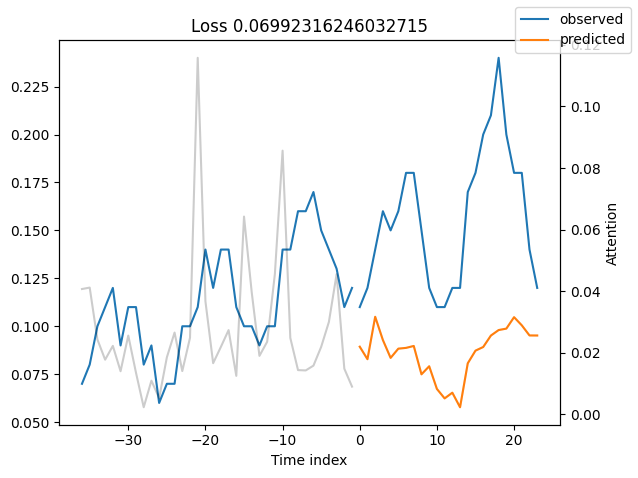

In [ ]:
# ── Cell 7: Vẽ prediction plot (chọn chuỗi có lỗi trung vị) ─────────────────
if x is not None:
    err_per_series = (actuals - point_predictions).abs().mean(dim=1)
    idx_plot = int(torch.argsort(err_per_series)[len(err_per_series) // 2].item())
    print(f"Vẽ chuỗi idx={idx_plot} (lỗi trung vị = {err_per_series[idx_plot].item():.4f} log-TWh)")
    _ = tft.plot_prediction(x, raw_predictions, idx=idx_plot, add_loss_to_title=True)
else:
    print("Không có x để vẽ")

In [ ]:
# ── Cell 8: Lưu model ────────────────────────────────────────────────────────
import shutil, os

os.makedirs("checkpoint", exist_ok=True)

# Lưu state cuối cùng
trainer.save_checkpoint("checkpoint/tft_v2_latest.ckpt")
print("✅ Đã lưu model cuối cùng → checkpoint/tft_v2_latest.ckpt")

# Copy best checkpoint
if trainer.checkpoint_callback and trainer.checkpoint_callback.best_model_path:
    best_path = trainer.checkpoint_callback.best_model_path
    shutil.copy(best_path, "checkpoint/tft_v2_best.ckpt")
    print(f"✅ Best model (val_loss tốt nhất) → checkpoint/tft_v2_best.ckpt")
    print(f"   (source: {best_path})")

print("\n📌 Load lại mô hình:")
print("   from pytorch_forecasting import TemporalFusionTransformer")
print("   model = TemporalFusionTransformer.load_from_checkpoint('checkpoint/tft_v2_best.ckpt')")

`weights_only` was not set, defaulting to `False`.


✅ Đã lưu model cuối cùng → checkpoint/tft_v2_latest.ckpt
✅ Best model (val_loss tốt nhất) → checkpoint/tft_v2_best.ckpt
   (source: lightning_logs\tft_v2_improved\version_5\checkpoints\tft_v2_best-epoch=03-val_loss=2.6922.ckpt)

📌 Load lại mô hình:
   from pytorch_forecasting import TemporalFusionTransformer
   model = TemporalFusionTransformer.load_from_checkpoint('checkpoint/tft_v2_best.ckpt')


In [ ]:
# ── Cell 9: Chuẩn bị cho Transfer Learning sang Vietnam ──────────────────────
# Lưu training dataset config để dùng khi fine-tune
import pickle, os

os.makedirs("checkpoint", exist_ok=True)

# Lưu training dataset (cần để từ_dataset() khi load model)
with open("checkpoint/training_dataset_v2.pkl", "wb") as f:
    pickle.dump(training, f)
print("✅ Đã lưu training dataset config → checkpoint/training_dataset_v2.pkl")

# Lưu thông tin LOG_TRANSFORM để biết khi load
config = {
    'LOG_TRANSFORM': LOG_TRANSFORM,
    'max_encoder_length': max_encoder_length,
    'max_prediction_length': max_prediction_length,
    'group_ids': ['entity', 'series'],
    'target': 'generation_TWh',
    'known_reals': known_reals,
    'unknown_reals': unknown_reals,
}
import json
with open("checkpoint/model_config_v2.json", "w") as f:
    json.dump(config, f, indent=2)
print("✅ Đã lưu model config → checkpoint/model_config_v2.json")
print()
print("📌 Thông tin quan trọng cho transfer learning:")
print(f"   LOG_TRANSFORM = {LOG_TRANSFORM}")
print(f"   → Khi chuẩn bị Vietnam data, cần áp dụng log1p transform")
print(f"   → Khi đánh giá, cần inverse transform bằng expm1")

✅ Đã lưu training dataset config → checkpoint/training_dataset_v2.pkl
✅ Đã lưu model config → checkpoint/model_config_v2.json

📌 Thông tin quan trọng cho transfer learning:
   LOG_TRANSFORM = False
   → Khi chuẩn bị Vietnam data, cần áp dụng log1p transform
   → Khi đánh giá, cần inverse transform bằng expm1
